<a href="https://colab.research.google.com/github/Ashutos0762/Reservoir_MBE_Solvers/blob/main/MBE_project_case2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Case 2: Volumetric Saturated-Oil Reservoir
# Calculating Saturations and Relative Permeability Ratio (krg/kro)

# Reservoir Properties
re = 700          # Drainage radius, ft
h = 100           # Net thickness, ft
phi = 0.2         # Porosity, fraction
Swi = 0.25        # Initial water saturation, fraction
Pi = 3600         # Initial/Bubble point pressure, psia
Boi = 1.48        # Initial Bo, bbl/STB

# Calculate OOIP (N) volumetrically in MMSTB
# Formula: N = pi * r^2 * h * phi * (1 - Swi) / (5.615 * Boi)
N = np.pi * (re**2) * h * phi * (1 - Swi) / (5.615 * Boi) / 1e6
print(f"Calculated N (Volumetric) = {N:.4f} MMSTB")

# Data from table
data = pd.DataFrame({
    'P': [3600, 3480, 3248, 3072, 2880, 2784, 2608, 2480, 2352, 2240],
    'Qo': [np.nan, 779.92, 560.06, 391.33, 289.13, 304.96, 233.01, 175.00, 158.50, 153.51],   # STB/day
    'Qg': [np.nan, 1.49618, 1.63759, 1.50281, 1.28058, 1.67928, 1.56996, 1.38978, 1.29939, 1.24187], # MMscf/day
    'Bo': [1.48, 1.42, 1.336, 1.2888, 1.2528, 1.2184, 1.1792, 1.152, 1.1272, 1.1056],    # bbl/STB
    'Rs': [1160, 1058.4, 914.4, 829.6, 766.4, 705.6, 632.8, 587.2, 545.6, 509.6],        # scf/STB
    'Bg': [np.nan, 0.0006376, 0.000672, 0.0007048, 0.0007328, 0.0007672, 0.000812, 0.000852, 0.000897, 0.000936], # bbl/scf
    'muo_mug': [4.48, 4.816, 5.792, 6.536, 7.48, 7.96, 8.88, 9.52, 10.24, 10.8],         # mu_o / mu_g
    'Np': [0, 0.0634532, 0.1656649, 0.2370831, 0.2898497, 0.3455046, 0.3880289, 0.4199666, 0.4488938, 0.476899] # MMSTB
})

data

Calculated N (Volumetric) = 2.7786 MMSTB


,P,Qo,Qg,Bo,Rs,Bg,muo_mug,Np
0,3600,NaN,NaN,1.4800,1160.0,NaN,4.480,0.000000
1,3480,779.92,1.49618,1.4200,1058.4,0.000638,4.816,0.063453
2,3248,560.06,1.63759,1.3360,914.4,0.000672,5.792,0.165665
3,3072,391.33,1.50281,1.2888,829.6,0.000705,6.536,0.237083
4,2880,289.13,1.28058,1.2528,766.4,0.000733,7.480,0.289850
5,2784,304.96,1.67928,1.2184,705.6,0.000767,7.960,0.345505
6,2608,233.01,1.56996,1.1792,632.8,0.000812,8.880,0.388029
7,2480,175.00,1.38978,1.1520,587.2,0.000852,9.520,0.419967
8,2352,158.50,1.29939,1.1272,545.6,0.000897,10.240,0.448894
9,2240,153.51,1.24187,1.1056,509.6,0.000936,10.800,0.476899


In [ ]:
# Create a mask to ignore the first row where production is zero
mask = data['Np'] > 0

# 1. Calculate Instantaneous GOR (scf/STB)
# Qg is in MMscf/day, so multiply by 1e6 to get scf/day
data.loc[mask, 'GOR'] = (data.loc[mask, 'Qg'] * 1e6) / data.loc[mask, 'Qo']

# 2. Calculate Oil Saturation (So)
# Formula: So = (1 - Swi) * (1 - Np/N) * (Bo/Boi)
data.loc[mask, 'So'] = (1 - Swi) * (1 - data.loc[mask, 'Np'] / N) * (data.loc[mask, 'Bo'] / Boi)

# 3. Calculate Gas Saturation (Sg)
# Formula: Sg = 1 - Swi - So
data.loc[mask, 'Sg'] = 1 - Swi - data.loc[mask, 'So']

# 4. Calculate Relative Permeability Ratio (krg/kro)
# Formula: krg/kro = (GOR - Rs) * (Bg / Bo) * (mu_g / mu_o)
# Note: The table gives mu_o/mu_g, so we divide by it.
data.loc[mask, 'krg_kro'] = (data.loc[mask, 'GOR'] - data.loc[mask, 'Rs']) * \
                            (data.loc[mask, 'Bg'] / data.loc[mask, 'Bo']) / \
                            data.loc[mask, 'muo_mug']

In [ ]:
# Select the columns to display and round them for readability
results_table = data[['P', 'Np', 'GOR', 'So', 'Sg', 'krg_kro']].dropna()

# Display the final table
print("Calculated Saturations and Relative Permeability Ratio:")
print("-" * 75)
print(results_table.round({'Np': 6, 'GOR': 3, 'So': 4, 'Sg': 4, 'krg_kro': 4}).to_string(index=False))

Calculated Saturations and Relative Permeability Ratio:
---------------------------------------------------------------------------
   P       Np      GOR     So     Sg  krg_kro
3480 0.063453 1918.376 0.7032 0.0468   0.0802
3248 0.165665 2923.955 0.6367 0.1133   0.1745
3072 0.237083 3840.263 0.5974 0.1526   0.2519
2880 0.289850 4429.080 0.5686 0.1814   0.2864
2784 0.345505 5506.558 0.5407 0.2093   0.3798
2608 0.388029 6737.737 0.5141 0.2359   0.4734
2480 0.419967 7941.600 0.4955 0.2545   0.5713
2352 0.448894 8198.044 0.4789 0.2711   0.5947
2240 0.476899 8089.831 0.4641 0.2859   0.5942


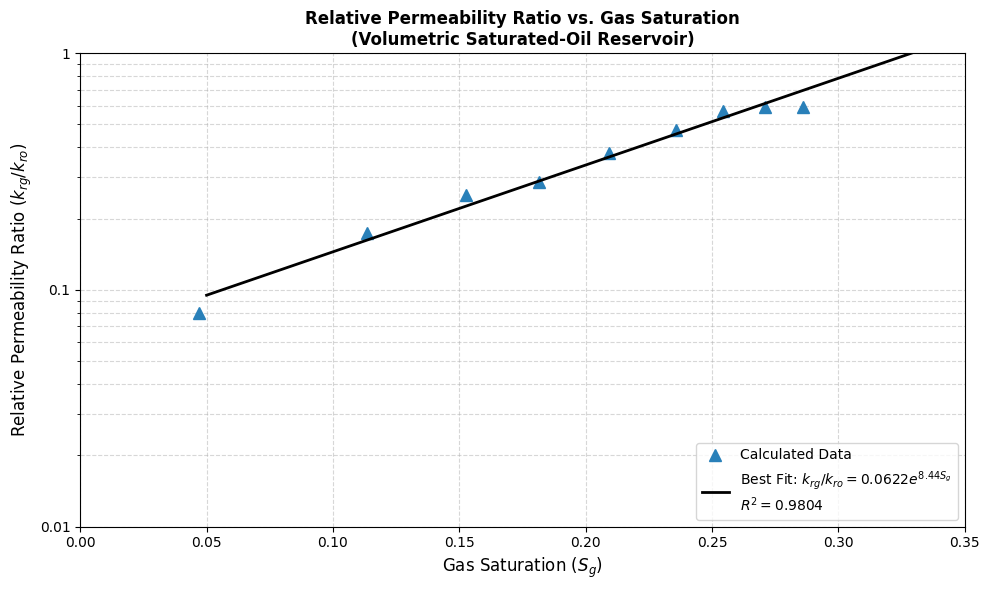

In [ ]:
# Extract the calculated values
Sg_values = results_table['Sg'].values
krg_kro_values = results_table['krg_kro'].values

# Fit a straight line to the semi-log plot (log(krg/kro) vs Sg)
# This finds coefficients a and b for the equation: krg/kro = a * exp(b * Sg)
slope, intercept, r_value, _, _ = linregress(Sg_values, np.log(krg_kro_values))
a = np.exp(intercept)
b = slope

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the calculated data points
ax.semilogy(Sg_values, krg_kro_values, '^', markersize=8, color='#2980b9', label='Calculated Data')

# Plot the best fit line
Sg_line = np.linspace(0.05, 0.35, 100)
krg_kro_line = a * np.exp(b * Sg_line)
ax.semilogy(Sg_line, krg_kro_line, 'k-', linewidth=2, label=f'Best Fit: $k_{{rg}}/k_{{ro}} = {a:.4f} e^{{{b:.2f} S_g}}$\n$R^2 = {r_value**2:.4f}$')

# Formatting
ax.set_title('Relative Permeability Ratio vs. Gas Saturation\n(Volumetric Saturated-Oil Reservoir)', fontweight='bold')
ax.set_xlabel('Gas Saturation ($S_g$)', fontsize=12)
ax.set_ylabel('Relative Permeability Ratio ($k_{rg}/k_{ro}$)', fontsize=12)
ax.grid(True, which="both", ls="--", alpha=0.5)
ax.set_xlim(0, 0.35)
ax.set_ylim(0.01, 1)

# Modify y-axis ticks to show actual numbers instead of scientific notation
from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:g}'))

ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("  CASE 2 SUMMARY")
print("  Volumetric Saturated-Oil Reservoir")
print("=" * 60)
print(f"  Volumetric OOIP (N):       {N:.4f} MMSTB")
print(f"  Initial Pressure (Pi=Pb):  {Pi} psia")
print()
print("  Gas Saturation & Relative Permeability:")
print(f"  - Final Gas Saturation (Sg): {Sg_values[-1]*100:.2f}% at {data['P'].iloc[-1]} psia")
print(f"  - Best Fit Equation:         krg/kro = {a:.4f} * e^({b:.2f} * Sg)")
print(f"  - Curve Fit Quality (R²):    {r_value**2:.4f}")
print()
print("  Takeaway:")
print("  - Below the bubble point, gas liberates and expands, becoming the primary drive mechanism.")
print("  - The MBE allows us to track changing fluid saturations (So, Sg) dynamically without core data.")
print("  - Generating krg/kro from field production data incorporates actual reservoir heterogeneity,")
print("    often making it more reliable than laboratory core measurements.")

  CASE 2 SUMMARY
  Volumetric Saturated-Oil Reservoir
  Volumetric OOIP (N):       2.7786 MMSTB
  Initial Pressure (Pi=Pb):  3600 psia

  Gas Saturation & Relative Permeability:
  - Final Gas Saturation (Sg): 28.59% at 2240 psia
  - Best Fit Equation:         krg/kro = 0.0622 * e^(8.44 * Sg)
  - Curve Fit Quality (R²):    0.9804

  Takeaway:
  - Below the bubble point, gas liberates and expands, becoming the primary drive mechanism.
  - The MBE allows us to track changing fluid saturations (So, Sg) dynamically without core data.
  - Generating krg/kro from field production data incorporates actual reservoir heterogeneity,
    often making it more reliable than laboratory core measurements.
